# 🏏 Bangla Sports Sentiment Analysis — SVM Classifier
## Thesis-Ready Complete Pipeline

**Dataset:** Bangla Sports Sentiment Analysis Dataset  
**Task:** Binary Sentiment Classification (Positive / Negative)  
**Model:** Support Vector Machine (LinearSVC) with TF-IDF Feature Engineering  
**Author:** [Your Name]  
**Date:** 2026

---

### Pipeline Overview
```
Raw Data → Preprocessing → Feature Engineering (TF-IDF Ensemble)
        → Model Training (SVM + LR + SGD) → Voting Ensemble
        → Evaluation → Thesis Diagrams & Charts
```

## 📦 Cell 1 — Install & Import Libraries

In [ ]:
# ── Install (run once in Colab) ──────────────────────────────────────────────
# !pip install scikit-learn pandas openpyxl numpy matplotlib seaborn scipy

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.sparse import hstack
from collections import Counter

from sklearn.model_selection      import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm                  import LinearSVC
from sklearn.linear_model         import LogisticRegression, SGDClassifier
from sklearn.calibration          import CalibratedClassifierCV
from sklearn.preprocessing        import LabelEncoder
from sklearn.metrics              import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'font.size':         12,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

COLORS = {'Positive': '#2ECC71', 'Negative': '#E74C3C',
          'primary': '#2C3E50', 'accent': '#3498DB', 'gold': '#F39C12'}

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 📂 Cell 2 — Load Dataset

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = '/content/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx'  # ← Change if needed
SEED      = 42

print('📂 Loading dataset...')
df = pd.read_excel(DATA_PATH, engine='openpyxl')

print(f'Raw shape   : {df.shape}')
print(f'Columns     : {df.columns.tolist()}')
print(f'\nNull values :\n{df.isnull().sum()}')
print(f'\nLabel distribution:\n{df["Category"].value_counts()}')
print(f'\nSample rows:')
df.head()

📂 Loading dataset...
Raw shape   : (82611, 3)
Columns     : ['Comment ', 'Category', 'Cleaned_Text']

Null values :
Comment           5
Category          0
Cleaned_Text    341
dtype: int64

Label distribution:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64

Sample rows:


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


## 📊 Cell 3 — Exploratory Data Analysis (EDA)

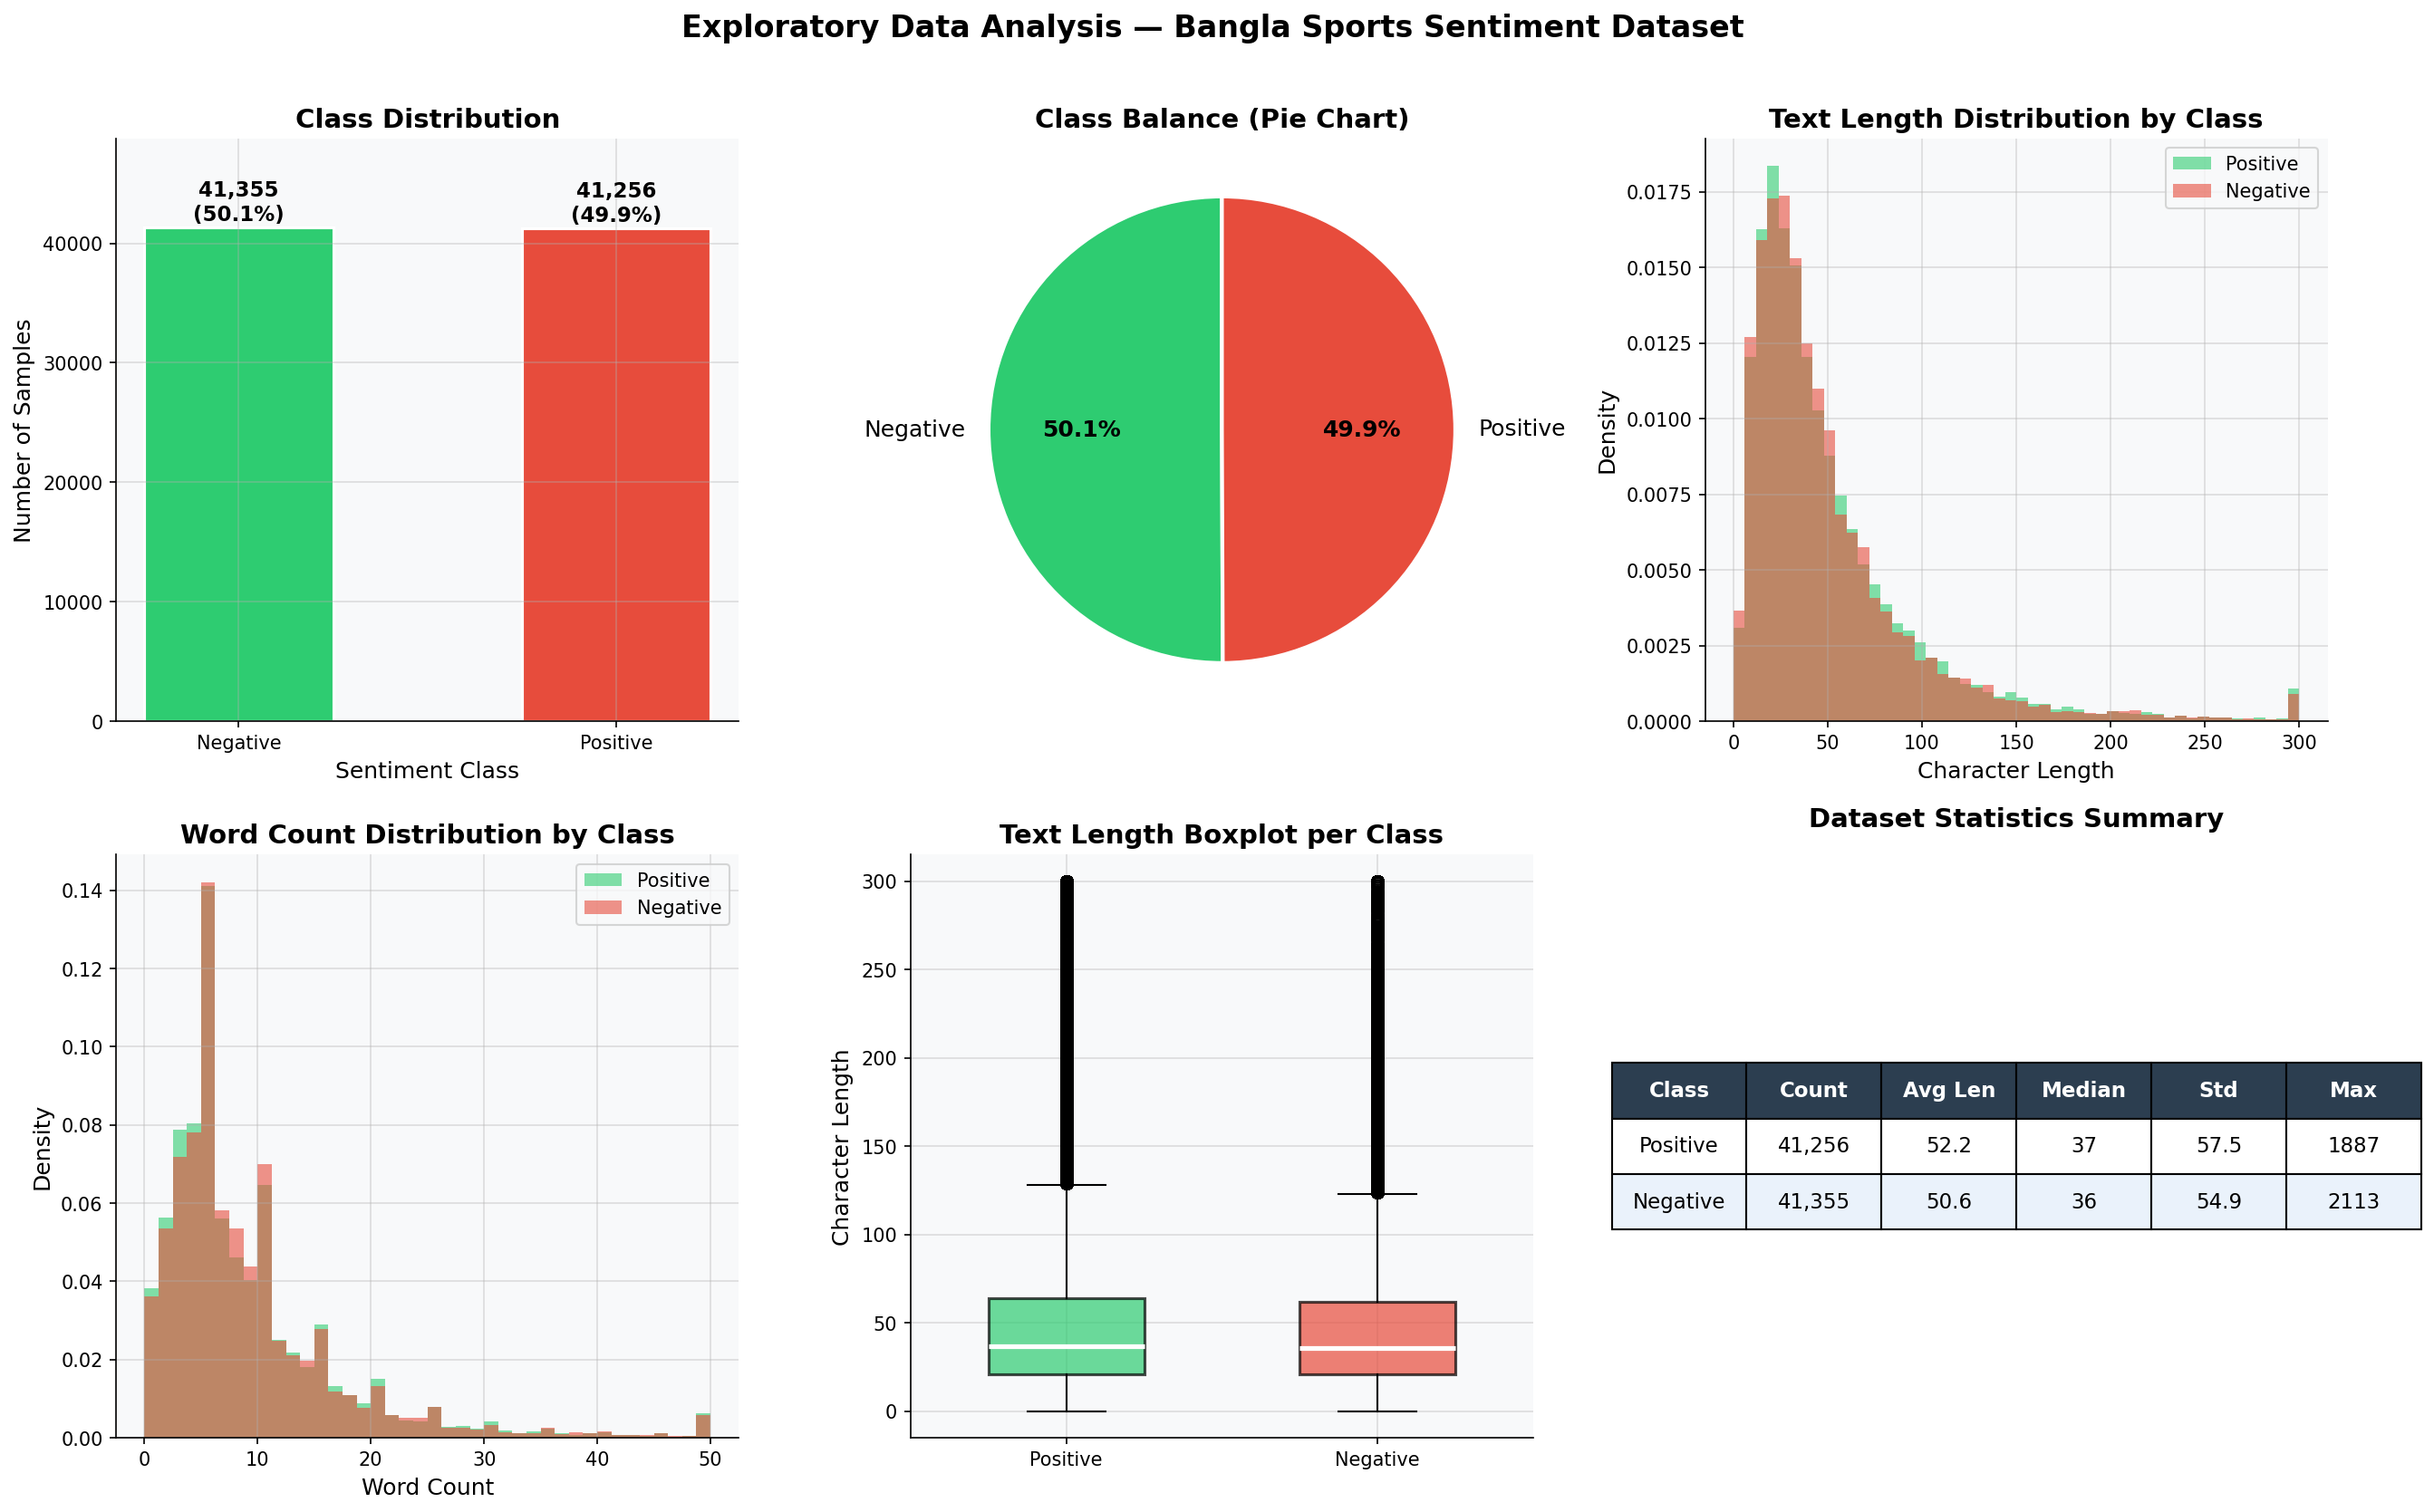

✅ EDA chart saved as 01_eda_analysis.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: Class Distribution + Text Length Analysis
# ─────────────────────────────────────────────────────────────────────────────
df['Comment ']    = df['Comment '].fillna('')
df['Cleaned_Text'] = df['Cleaned_Text'].fillna('')

df['text_length']   = df['Comment '].str.len()
df['word_count']    = df['Comment '].str.split().str.len()
df['cleaned_length'] = df['Cleaned_Text'].str.len()

label_counts = df['Category'].value_counts()
label_pct    = df['Category'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Exploratory Data Analysis — Bangla Sports Sentiment Dataset',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Class distribution — Bar
ax = axes[0, 0]
bars = ax.bar(label_counts.index, label_counts.values,
              color=[COLORS['Positive'], COLORS['Negative']],
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, cnt, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(label_counts.values) * 1.18)

# 2. Class distribution — Pie
ax = axes[0, 1]
wedges, texts, autotexts = ax.pie(
    label_counts.values, labels=label_counts.index,
    colors=[COLORS['Positive'], COLORS['Negative']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Class Balance (Pie Chart)', fontweight='bold')

# 3. Text length distribution by class
ax = axes[0, 2]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['text_length']
    ax.hist(subset.clip(upper=300), bins=50, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Text Length Distribution by Class', fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Density')
ax.legend()

# 4. Word count distribution
ax = axes[1, 0]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['word_count']
    ax.hist(subset.clip(upper=50), bins=40, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Word Count Distribution by Class', fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Density')
ax.legend()

# 5. Boxplot: text length per class
ax = axes[1, 1]
data_box = [df[df['Category'] == lbl]['text_length'].clip(upper=300).values
            for lbl in ['Positive', 'Negative']]
bp = ax.boxplot(data_box, patch_artist=True, labels=['Positive', 'Negative'],
                widths=0.5,
                boxprops={'linewidth': 1.5},
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], [COLORS['Positive'], COLORS['Negative']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Text Length Boxplot per Class', fontweight='bold')
ax.set_ylabel('Character Length')

# 6. Stats summary table
ax = axes[1, 2]
ax.axis('off')
stats_data = []
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['text_length']
    stats_data.append([label,
                        f'{len(subset):,}',
                        f'{subset.mean():.1f}',
                        f'{subset.median():.0f}',
                        f'{subset.std():.1f}',
                        f'{subset.max():.0f}'])
table = ax.table(
    cellText=stats_data,
    colLabels=['Class', 'Count', 'Avg Len', 'Median', 'Std', 'Max'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.2)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax.set_title('Dataset Statistics Summary', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('01_eda_analysis.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ EDA chart saved as 01_eda_analysis.png')

## 🧹 Cell 4 — Text Preprocessing

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TEXT CLEANING FUNCTION
# Strategy: Use the dataset's pre-cleaned 'Cleaned_Text' column as primary.
# Fall back to raw 'Comment ' if Cleaned_Text is too short.
# ─────────────────────────────────────────────────────────────────────────────

def clean_bangla(text: str) -> str:
    """
    Bangla text cleaner:
    - Remove URLs, emails, HTML tags
    - Remove English characters and digits
    - Keep only Bangla Unicode (\u0980-\u09FF) + punctuation
    - Normalize repeated punctuation
    - Normalize whitespace
    """
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)        # URLs
    text = re.sub(r'<.*?>', '', text)                    # HTML tags
    text = re.sub(r'\S+@\S+', '', text)                  # Emails
    text = re.sub(r'[A-Za-z0-9]', '', text)              # English + digits
    text = re.sub(r'[^\u0980-\u09FF\s।,!?]', ' ', text) # Non-Bangla symbols
    text = re.sub(r'([।,!?])\1+', r'\1', text)          # Repeated punctuation
    text = re.sub(r'\s+', ' ', text).strip()             # Whitespace normalize
    return text

# Apply cleaning to raw comment
print('🧹 Cleaning raw text...')
df['raw_cleaned'] = df['Comment '].apply(clean_bangla)

# Use Cleaned_Text if it exists and is long enough; else use raw_cleaned
df['final_text'] = df.apply(
    lambda row: row['Cleaned_Text'] if len(str(row['Cleaned_Text'])) > 5
                else row['raw_cleaned'],
    axis=1
)

# Remove rows where both are empty
before = len(df)
df = df[df['final_text'].str.len() > 3].reset_index(drop=True)
df = df[df['raw_cleaned'].str.len() > 3].reset_index(drop=True)
print(f'Removed {before - len(df)} empty/too-short rows.')
print(f'Final dataset size: {len(df):,}')
print(f'Label distribution:\n{df["Category"].value_counts()}')

🧹 Cleaning raw text...
Removed 538 empty/too-short rows.
Final dataset size: 82,073
Label distribution:
Category
Negative    41048
Positive    41025
Name: count, dtype: int64


## ✂️ Cell 5 — Train / Validation / Test Split

Label mapping: {'Negative': np.int64(0), 'Positive': np.int64(1)}
Train : 57,451 samples (70%)
Val   : 12,311 samples (15%)
Test  : 12,311 samples (15%)


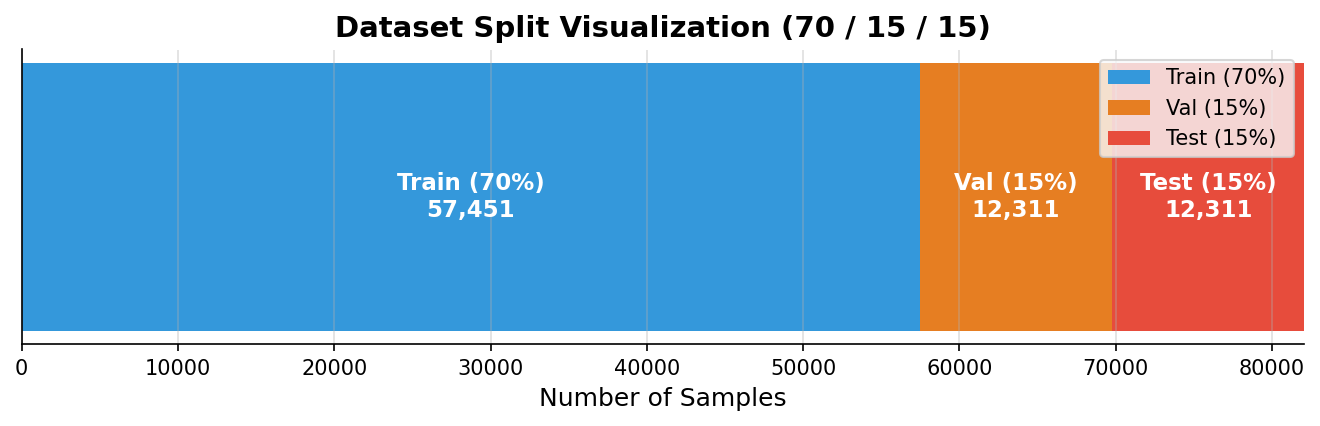

✅ Split chart saved as 02_dataset_split.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LABEL ENCODING + SPLIT  (70 / 15 / 15)
# ─────────────────────────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['Category'])   # Negative=0, Positive=1
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_raw   = df['raw_cleaned']   # cleaned raw text
X_clean = df['Cleaned_Text'].fillna('')  # stemmed text from dataset

# First split: 70% train, 30% temp
(
    X_raw_train, X_raw_temp,
    X_cl_train,  X_cl_temp,
    y_train,     y_temp
) = train_test_split(
    X_raw, X_clean, y,
    test_size=0.30, random_state=SEED, stratify=y
)

# Second split: 15% val, 15% test
(
    X_raw_val,  X_raw_test,
    X_cl_val,   X_cl_test,
    y_val,      y_test
) = train_test_split(
    X_raw_temp, X_cl_temp, y_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_raw_train):>6,} samples ({len(X_raw_train)/len(y)*100:.0f}%)')
print(f'Val   : {len(X_raw_val):>6,} samples ({len(X_raw_val)/len(y)*100:.0f}%)')
print(f'Test  : {len(X_raw_test):>6,} samples ({len(X_raw_test)/len(y)*100:.0f}%)')

# Visualize split
fig, ax = plt.subplots(figsize=(9, 3))
splits = {'Train (70%)': len(X_raw_train),
          'Val (15%)':   len(X_raw_val),
          'Test (15%)':  len(X_raw_test)}
colors_split = ['#3498DB', '#E67E22', '#E74C3C']
left = 0
for (name, val), color in zip(splits.items(), colors_split):
    ax.barh(0, val, left=left, color=color, height=0.5, label=name)
    ax.text(left + val/2, 0, f'{name}\n{val:,}',
            ha='center', va='center', fontweight='bold',
            fontsize=11, color='white')
    left += val
ax.set_xlim(0, len(y))
ax.set_yticks([])
ax.set_xlabel('Number of Samples')
ax.set_title('Dataset Split Visualization (70 / 15 / 15)', fontweight='bold')
ax.legend(loc='upper right')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('02_dataset_split.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Split chart saved as 02_dataset_split.png')

## ⚙️ Cell 6 — Feature Engineering (TF-IDF Ensemble)

⚙️  Building TF-IDF feature matrices...
Total feature dimensions : 324,240
Train feature matrix     : (57451, 324240)
Val feature matrix       : (12311, 324240)
Test feature matrix      : (12311, 324240)


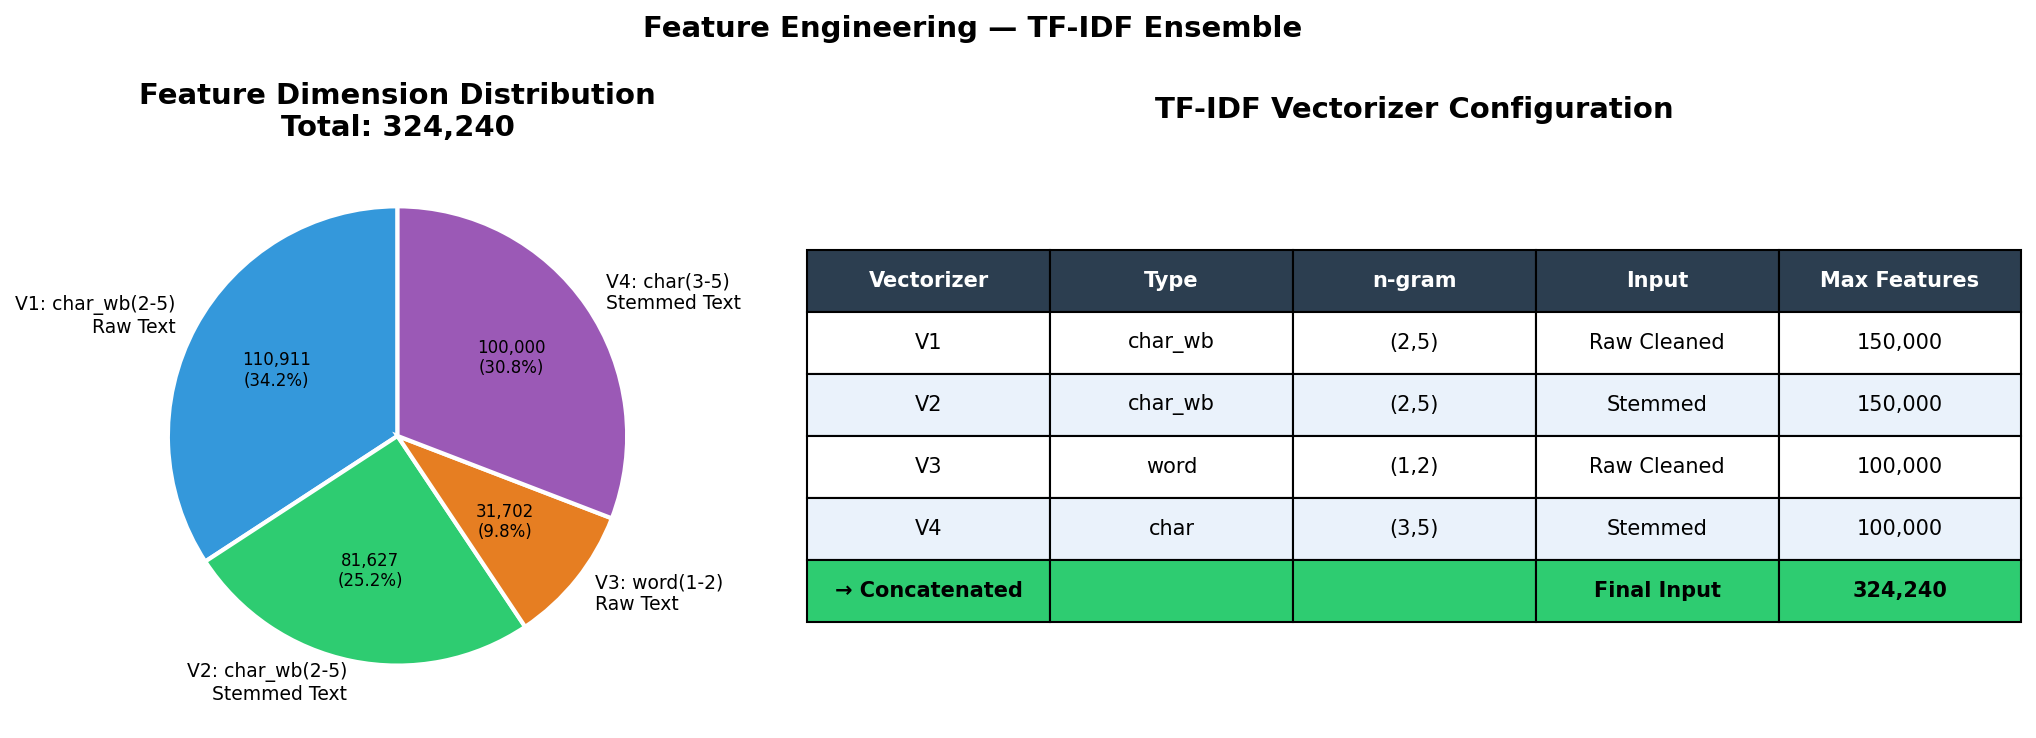

✅ Feature engineering chart saved as 03_feature_engineering.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
#
# We build 4 TF-IDF feature matrices and concatenate them:
#  V1: char_wb (2,5) on raw cleaned text  — captures morphology
#  V2: char_wb (2,5) on stemmed text      — captures root forms
#  V3: word (1,2) on raw cleaned text     — unigram + bigram
#  V4: char (3,5) on stemmed text         — sub-word features
#
# Reason for char n-grams: Bangla is morphologically rich — character-level
# features capture word stems, suffixes, and inflections better than
# simple word tokenization.
# ─────────────────────────────────────────────────────────────────────────────

print('⚙️  Building TF-IDF feature matrices...')

V1 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                     max_features=150_000, sublinear_tf=True, min_df=2)
V2 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                     max_features=150_000, sublinear_tf=True, min_df=2)
V3 = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                     max_features=100_000, sublinear_tf=True, min_df=2)
V4 = TfidfVectorizer(analyzer='char', ngram_range=(3, 5),
                     max_features=100_000, sublinear_tf=True, min_df=2)

# Fit on training data only — transform all splits
X_train_feat = hstack([
    V1.fit_transform(X_raw_train),
    V2.fit_transform(X_cl_train),
    V3.fit_transform(X_raw_train),
    V4.fit_transform(X_cl_train)
])
X_val_feat = hstack([
    V1.transform(X_raw_val),
    V2.transform(X_cl_val),
    V3.transform(X_raw_val),
    V4.transform(X_cl_val)
])
X_test_feat = hstack([
    V1.transform(X_raw_test),
    V2.transform(X_cl_test),
    V3.transform(X_raw_test),
    V4.transform(X_cl_test)
])

total_features = X_train_feat.shape[1]
print(f'Total feature dimensions : {total_features:,}')
print(f'Train feature matrix     : {X_train_feat.shape}')
print(f'Val feature matrix       : {X_val_feat.shape}')
print(f'Test feature matrix      : {X_test_feat.shape}')

# Feature contribution chart
feat_names = [
    'V1: char_wb(2-5)\nRaw Text',
    'V2: char_wb(2-5)\nStemmed Text',
    'V3: word(1-2)\nRaw Text',
    'V4: char(3-5)\nStemmed Text'
]
feat_sizes = [
    V1.transform(X_raw_train[:1]).shape[1],
    V2.transform(X_cl_train[:1]).shape[1],
    V3.transform(X_raw_train[:1]).shape[1],
    V4.transform(X_cl_train[:1]).shape[1],
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Engineering — TF-IDF Ensemble', fontweight='bold', fontsize=14)

# Pie chart of feature dimensions
feat_colors = ['#3498DB', '#2ECC71', '#E67E22', '#9B59B6']
wedges, texts, autotexts = ax1.pie(
    feat_sizes, labels=feat_names, colors=feat_colors,
    autopct=lambda p: f'{int(p*total_features/100):,}\n({p:.1f}%)',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(8)
ax1.set_title(f'Feature Dimension Distribution\nTotal: {total_features:,}', fontweight='bold')

# Architecture diagram (text-based)
ax2.axis('off')
rows = [
    ['Vectorizer', 'Type', 'n-gram', 'Input', 'Max Features'],
    ['V1', 'char_wb', '(2,5)', 'Raw Cleaned', '150,000'],
    ['V2', 'char_wb', '(2,5)', 'Stemmed',     '150,000'],
    ['V3', 'word',    '(1,2)', 'Raw Cleaned', '100,000'],
    ['V4', 'char',    '(3,5)', 'Stemmed',     '100,000'],
    ['→ Concatenated', '', '', 'Final Input', f'{total_features:,}'],
]
tbl = ax2.table(cellText=rows[1:], colLabels=rows[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.4, 2.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    elif r == len(rows) - 1:
        cell.set_facecolor('#2ECC71')
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax2.set_title('TF-IDF Vectorizer Configuration', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('03_feature_engineering.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Feature engineering chart saved as 03_feature_engineering.png')

## 🤖 Cell 7 — Model Training (SVM + LR + SGD)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL TRAINING
#
# Three classifiers are trained on the same feature matrix:
#  1. SVM (LinearSVC + CalibratedClassifierCV)  — main model
#  2. Logistic Regression (SAGA solver)          — strong baseline
#  3. SGD (modified_huber loss)                  — fast SVM approximation
#
# Final predictions = Soft Voting Ensemble of all three
# ─────────────────────────────────────────────────────────────────────────────

print('🤖 Training models...')
print('─' * 50)

# 1. SVM
print('[1/3] Training SVM (LinearSVC)...')
svm_base = LinearSVC(C=3.0, max_iter=5000, random_state=SEED)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train_feat, y_train)
svm_val_acc = accuracy_score(y_val, svm_model.predict(X_val_feat))
print(f'   SVM Validation Accuracy: {svm_val_acc:.4f}')

# 2. Logistic Regression
print('[2/3] Training Logistic Regression...')
lr_model = LogisticRegression(C=3.0, max_iter=1000, solver='saga',
                               n_jobs=-1, random_state=SEED)
lr_model.fit(X_train_feat, y_train)
lr_val_acc = accuracy_score(y_val, lr_model.predict(X_val_feat))
print(f'   LR  Validation Accuracy: {lr_val_acc:.4f}')

# 3. SGD
print('[3/3] Training SGD Classifier...')
sgd_model = SGDClassifier(loss='modified_huber', alpha=1e-5,
                           max_iter=200, random_state=SEED, n_jobs=-1)
sgd_model.fit(X_train_feat, y_train)
sgd_val_acc = accuracy_score(y_val, sgd_model.predict(X_val_feat))
print(f'   SGD Validation Accuracy: {sgd_val_acc:.4f}')

# 4. Voting Ensemble
print('\n[Ensemble] Soft Voting of all three models...')
svm_prob  = svm_model.predict_proba(X_val_feat)
lr_prob   = lr_model.predict_proba(X_val_feat)
sgd_prob  = sgd_model.predict_proba(X_val_feat)
avg_prob  = (svm_prob + lr_prob + sgd_prob) / 3
ens_preds = np.argmax(avg_prob, axis=1)
ens_val_acc = accuracy_score(y_val, ens_preds)
print(f'   Ensemble Validation Accuracy: {ens_val_acc:.4f}')

print('\n' + '─' * 50)
print('✅ Training complete!')

🤖 Training models...
──────────────────────────────────────────────────
[1/3] Training SVM (LinearSVC)...
   SVM Validation Accuracy: 0.8138
[2/3] Training Logistic Regression...
   LR  Validation Accuracy: 0.8151
[3/3] Training SGD Classifier...
   SGD Validation Accuracy: 0.8071

[Ensemble] Soft Voting of all three models...
   Ensemble Validation Accuracy: 0.8157

──────────────────────────────────────────────────
✅ Training complete!


## 📈 Cell 8 — Model Comparison Chart

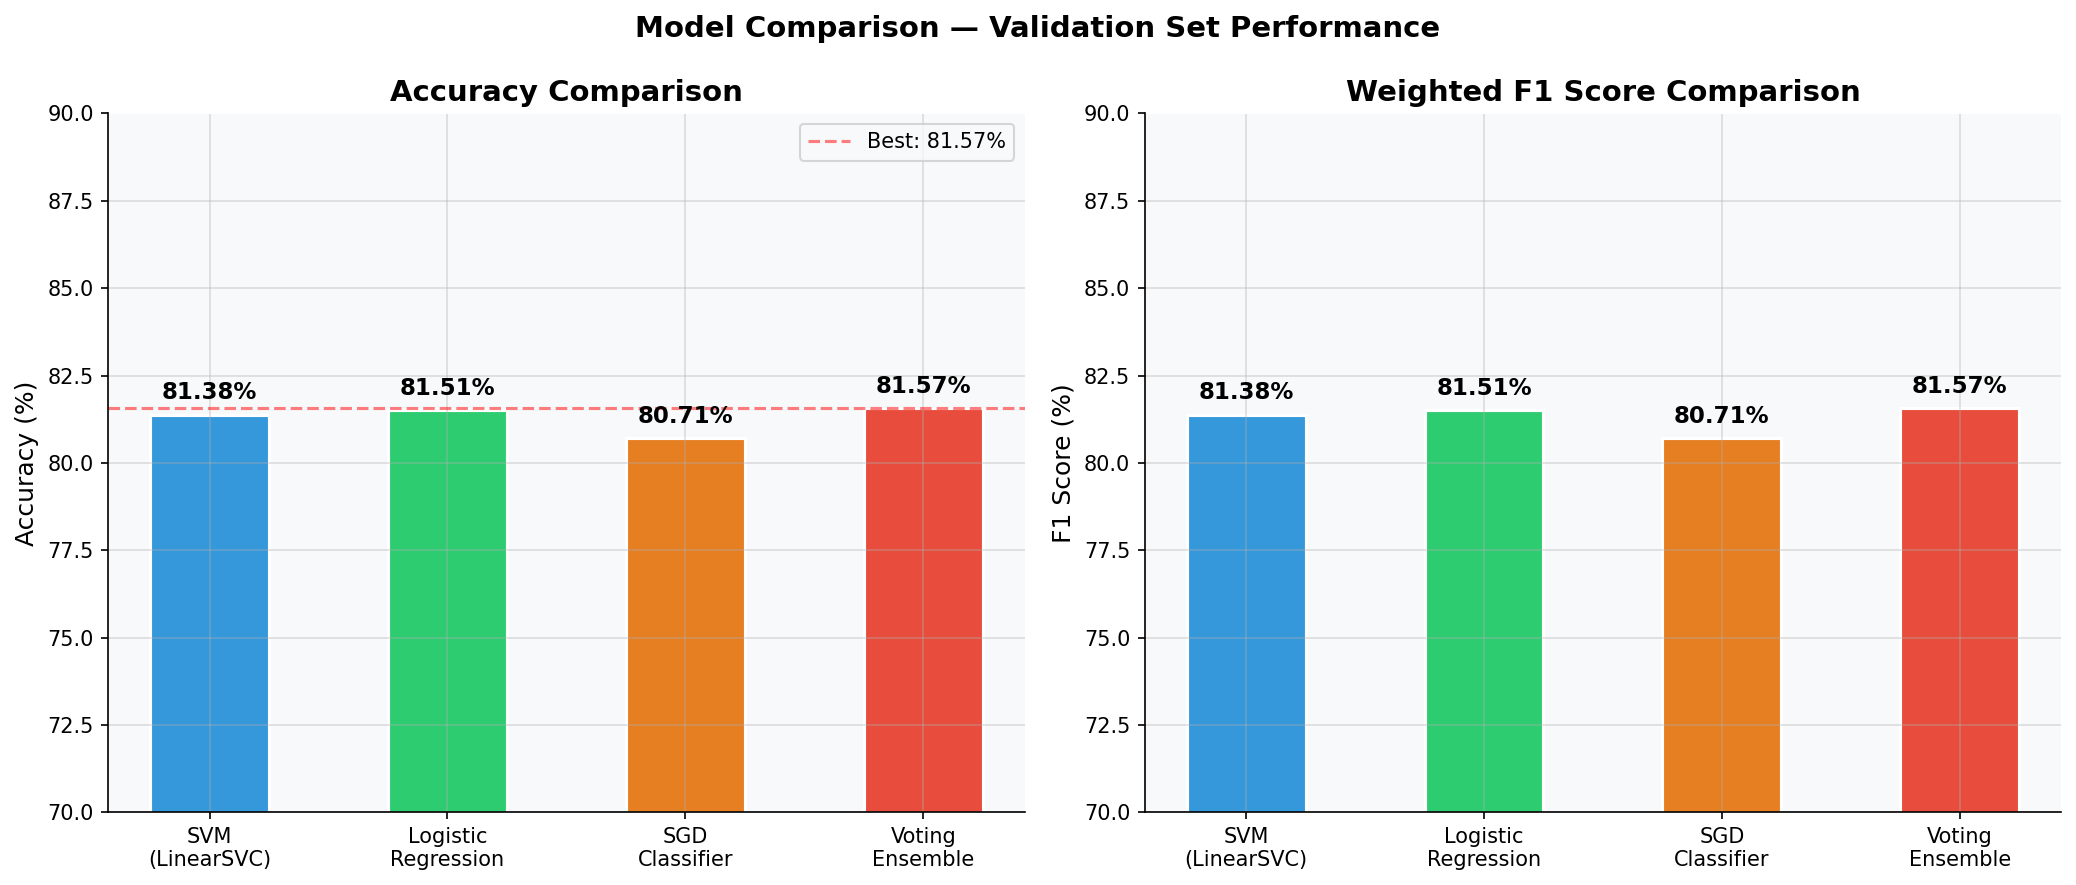

✅ Model comparison chart saved as 04_model_comparison.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL COMPARISON — Validation Set
# ─────────────────────────────────────────────────────────────────────────────
model_names  = ['SVM\n(LinearSVC)', 'Logistic\nRegression', 'SGD\nClassifier', 'Voting\nEnsemble']
model_colors = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

val_accuracies = [svm_val_acc, lr_val_acc, sgd_val_acc, ens_val_acc]

# Also compute F1
svm_val_f1  = f1_score(y_val, svm_model.predict(X_val_feat),  average='weighted')
lr_val_f1   = f1_score(y_val, lr_model.predict(X_val_feat),   average='weighted')
sgd_val_f1  = f1_score(y_val, sgd_model.predict(X_val_feat),  average='weighted')
ens_val_f1  = f1_score(y_val, ens_preds, average='weighted')
val_f1s     = [svm_val_f1, lr_val_f1, sgd_val_f1, ens_val_f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison — Validation Set Performance', fontweight='bold', fontsize=14)

# Accuracy bar chart
ax = axes[0]
bars = ax.bar(model_names, [v * 100 for v in val_accuracies],
              color=model_colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, val_accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(70, 90)
ax.set_title('Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.axhline(y=max(val_accuracies)*100, color='red', linestyle='--',
           alpha=0.5, label=f'Best: {max(val_accuracies)*100:.2f}%')
ax.legend()

# F1 bar chart
ax = axes[1]
bars = ax.bar(model_names, [v * 100 for v in val_f1s],
              color=model_colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, val_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(70, 90)
ax.set_title('Weighted F1 Score Comparison', fontweight='bold')
ax.set_ylabel('F1 Score (%)')

plt.tight_layout()
plt.savefig('04_model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Model comparison chart saved as 04_model_comparison.png')

## 🎯 Cell 9 — Final Test Set Evaluation

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL EVALUATION ON TEST SET (unseen data)
# Using the Voting Ensemble (best model)
# ─────────────────────────────────────────────────────────────────────────────

# Get test predictions from all models
svm_test_prob  = svm_model.predict_proba(X_test_feat)
lr_test_prob   = lr_model.predict_proba(X_test_feat)
sgd_test_prob  = sgd_model.predict_proba(X_test_feat)
avg_test_prob  = (svm_test_prob + lr_test_prob + sgd_test_prob) / 3
y_pred         = np.argmax(avg_test_prob, axis=1)
y_prob_pos     = avg_test_prob[:, 1]   # probability of Positive class

# Core metrics
test_acc  = accuracy_score(y_test, y_pred)
test_f1   = f1_score(y_test, y_pred, average='weighted')
test_prec = precision_score(y_test, y_pred, average='weighted')
test_rec  = recall_score(y_test, y_pred, average='weighted')
test_auc  = roc_auc_score(y_test, y_prob_pos)

print('=' * 55)
print('  FINAL TEST SET RESULTS — Voting Ensemble')
print('=' * 55)
print(f'  Accuracy          : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Weighted F1 Score : {test_f1:.4f}  ({test_f1*100:.2f}%)')
print(f'  Precision         : {test_prec:.4f}')
print(f'  Recall            : {test_rec:.4f}')
print(f'  ROC-AUC           : {test_auc:.4f}')
print('=' * 55)

print('\n📋 Per-Class Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

  FINAL TEST SET RESULTS — Voting Ensemble
  Accuracy          : 0.8197  (81.97%)
  Weighted F1 Score : 0.8197  (81.97%)
  Precision         : 0.8197
  Recall            : 0.8197
  ROC-AUC           : 0.8926

📋 Per-Class Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.82      0.82      6157
    Positive       0.82      0.82      0.82      6154

    accuracy                           0.82     12311
   macro avg       0.82      0.82      0.82     12311
weighted avg       0.82      0.82      0.82     12311



## 📊 Cell 10 — Confusion Matrix

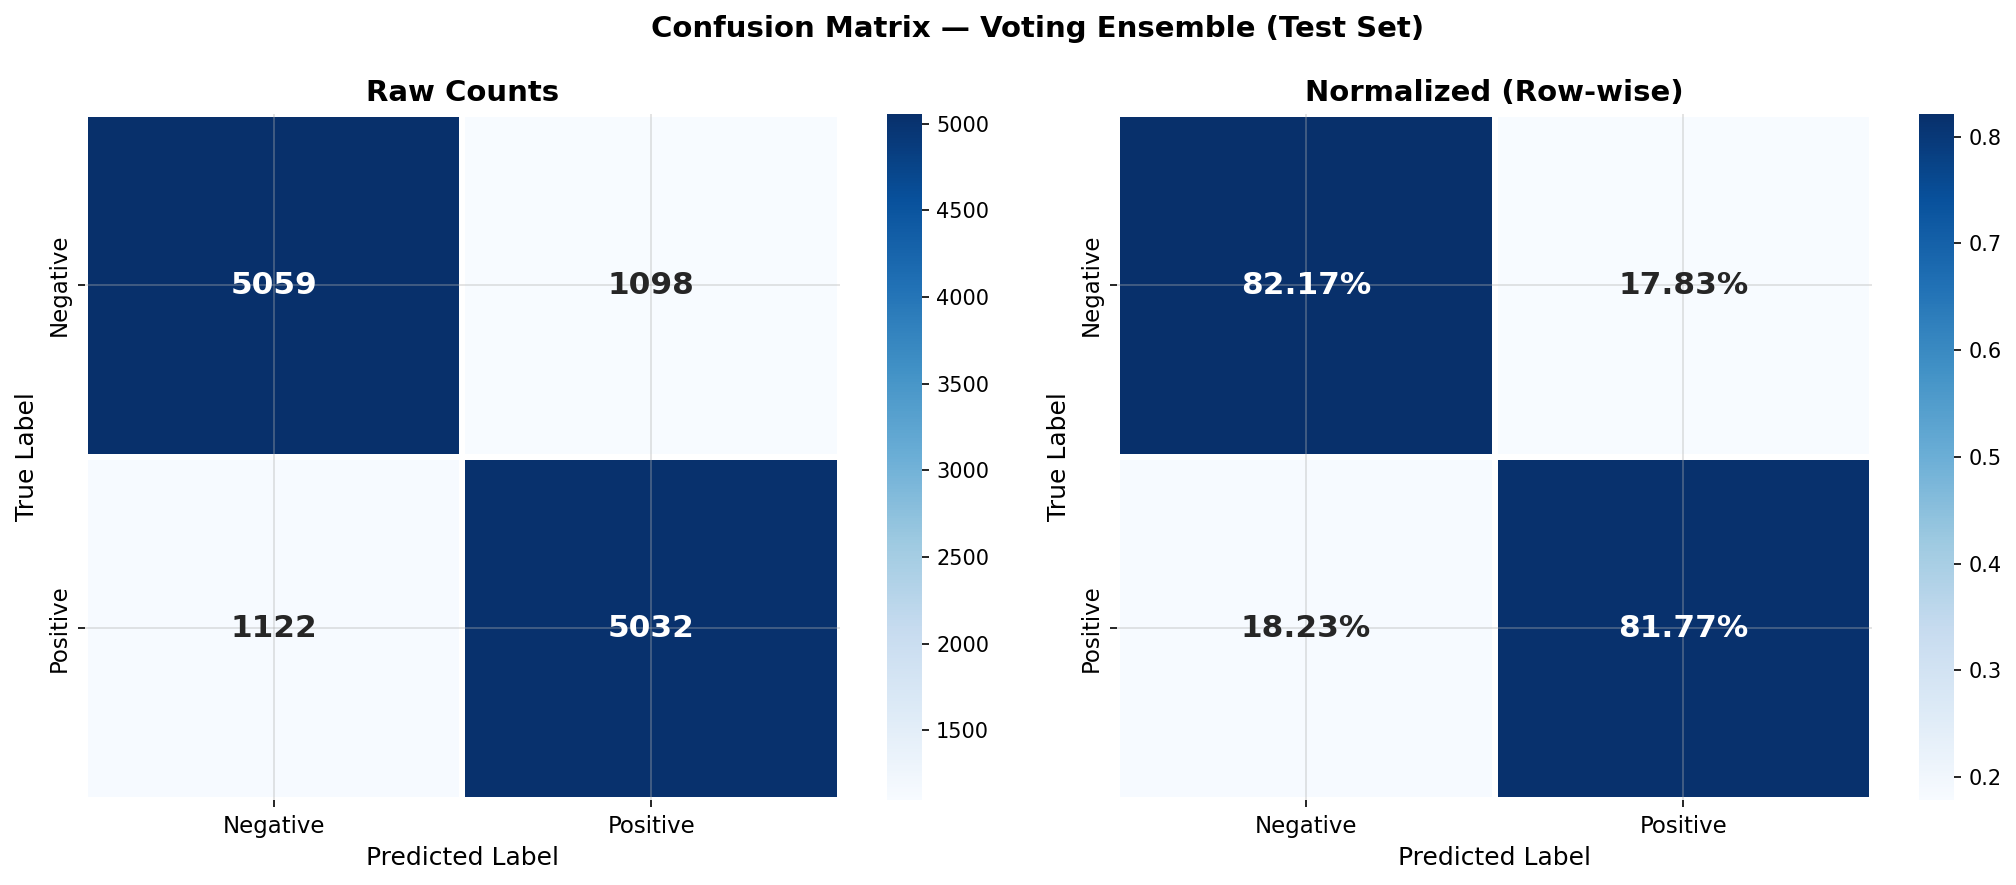

✅ Confusion matrix saved as 05_confusion_matrix.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX — Raw + Normalized
# ─────────────────────────────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix — Voting Ensemble (Test Set)',
             fontweight='bold', fontsize=14)

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Raw Counts', 'Normalized (Row-wise)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        xticklabels=le.classes_, yticklabels=le.classes_,
        cmap='Blues', ax=ax, linewidths=2, linecolor='white',
        annot_kws={'size': 15, 'weight': 'bold'}
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('05_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Confusion matrix saved as 05_confusion_matrix.png')

## 📉 Cell 11 — ROC Curve & Precision-Recall Curve

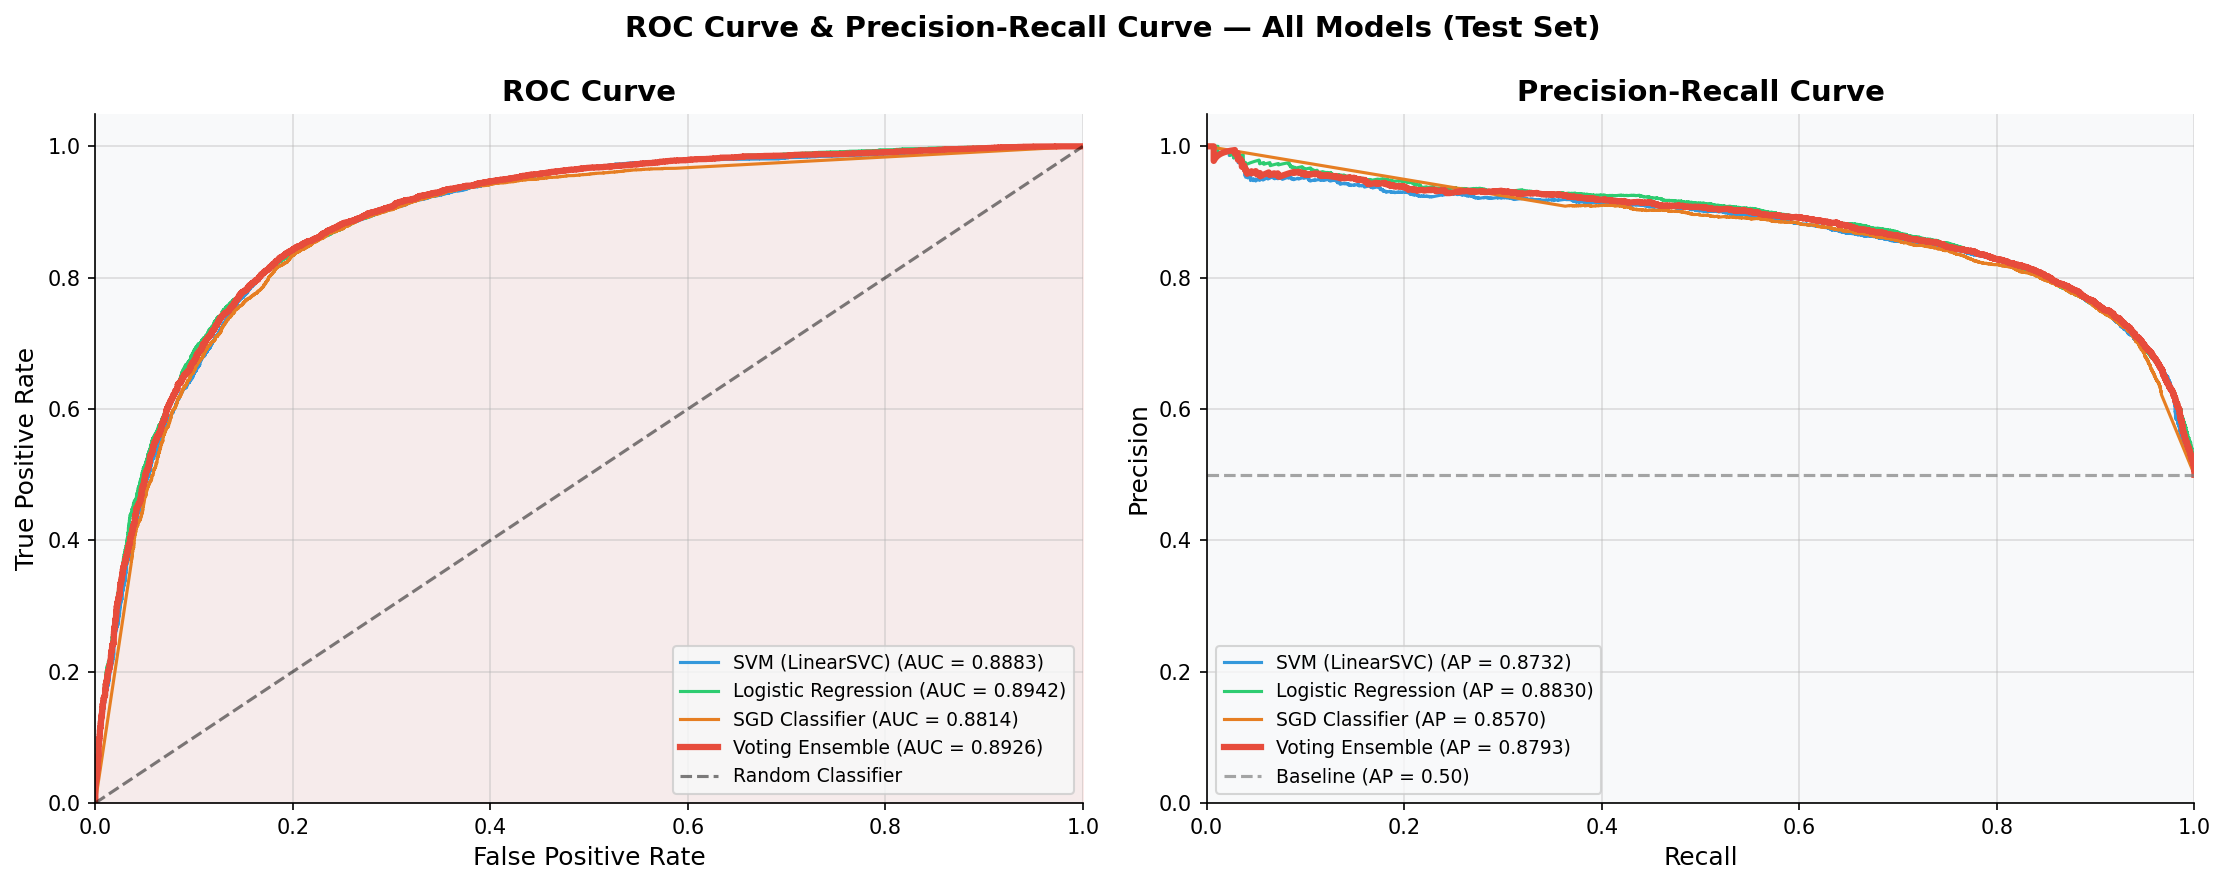

✅ ROC & PR curves saved as 06_roc_pr_curves.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ROC CURVE + PRECISION-RECALL CURVE — All models + Ensemble
# ─────────────────────────────────────────────────────────────────────────────
models_for_curve = {
    'SVM (LinearSVC)':    svm_test_prob[:, 1],
    'Logistic Regression': lr_test_prob[:, 1],
    'SGD Classifier':     sgd_test_prob[:, 1],
    'Voting Ensemble':    avg_test_prob[:, 1],
}
curve_colors = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Curve & Precision-Recall Curve — All Models (Test Set)',
             fontweight='bold', fontsize=14)

# ROC Curve
ax = axes[0]
for (name, prob), color in zip(models_for_curve.items(), curve_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc     = auc(fpr, tpr)
    lw = 3 if name == 'Voting Ensemble' else 1.5
    ax.plot(fpr, tpr, color=color, lw=lw,
            label=f'{name} (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.fill_between(
    *roc_curve(y_test, avg_test_prob[:, 1])[:2],
    alpha=0.08, color='#E74C3C'
)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

# Precision-Recall Curve
ax = axes[1]
for (name, prob), color in zip(models_for_curve.items(), curve_colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    lw = 3 if name == 'Voting Ensemble' else 1.5
    ax.plot(rec, prec, color=color, lw=lw,
            label=f'{name} (AP = {ap:.4f})')
baseline = y_test.sum() / len(y_test)
ax.axhline(y=baseline, color='gray', linestyle='--',
           lw=1.5, alpha=0.7, label=f'Baseline (AP = {baseline:.2f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('06_roc_pr_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ ROC & PR curves saved as 06_roc_pr_curves.png')

## 🔁 Cell 12 — Cross-Validation

🔁 Running 5-Fold Cross-Validation (this may take a few minutes)...

Cross-Validation Results (5-Fold):
  Accuracy : 0.7948 ± 0.0028
  F1 Score : 0.7948 ± 0.0028
  Per-fold accuracy: ['0.7956', '0.7922', '0.7971', '0.7982', '0.7910']


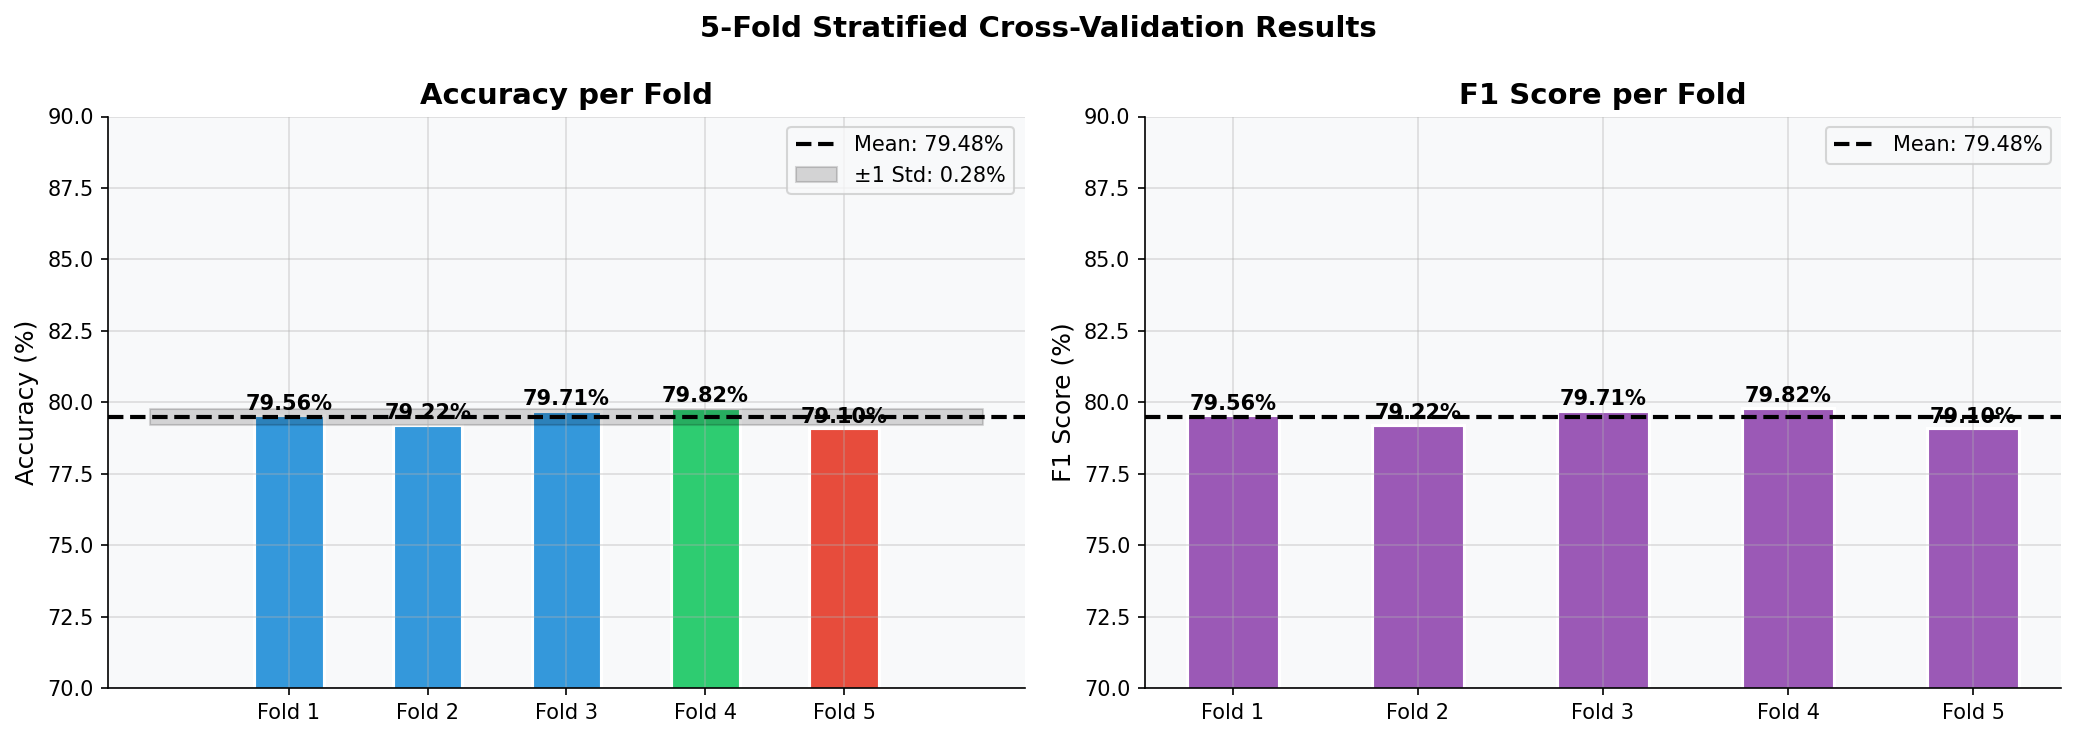

✅ Cross-validation chart saved as 07_cross_validation.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5-FOLD STRATIFIED CROSS-VALIDATION
# Run on the full training set with the best single model (LR)
# ─────────────────────────────────────────────────────────────────────────────
print('🔁 Running 5-Fold Cross-Validation (this may take a few minutes)...')

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer as TFIDF

# Use single vectorizer + LR for CV (memory efficient)
cv_pipe = Pipeline([
    ('tfidf', TFIDF(analyzer='char_wb', ngram_range=(2, 5),
                    max_features=150_000, sublinear_tf=True, min_df=2)),
    ('clf',   LogisticRegression(C=3.0, max_iter=1000,
                                 solver='saga', n_jobs=-1, random_state=SEED))
])

# Combine train + val for CV
X_cv = pd.concat([X_raw_train, X_raw_val]).reset_index(drop=True)
y_cv = np.concatenate([y_train, y_val])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_acc = cross_val_score(cv_pipe, X_cv, y_cv, cv=skf,
                          scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(cv_pipe, X_cv, y_cv, cv=skf,
                          scoring='f1_weighted', n_jobs=-1)

print(f'\nCross-Validation Results (5-Fold):')
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'  Per-fold accuracy: {[f"{v:.4f}" for v in cv_acc]}')

# CV Results chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Stratified Cross-Validation Results', fontweight='bold', fontsize=14)

fold_labels = [f'Fold {i+1}' for i in range(5)]

# Accuracy per fold
ax = axes[0]
bar_colors = ['#E74C3C' if v == cv_acc.min() else
              '#2ECC71' if v == cv_acc.max() else '#3498DB'
              for v in cv_acc]
bars = ax.bar(fold_labels, cv_acc * 100, color=bar_colors,
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cv_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val*100:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=10)
ax.axhline(y=cv_acc.mean()*100, color='black', linestyle='--',
           lw=2, label=f'Mean: {cv_acc.mean()*100:.2f}%')
ax.fill_between(range(-1, 6),
                (cv_acc.mean() - cv_acc.std()) * 100,
                (cv_acc.mean() + cv_acc.std()) * 100,
                alpha=0.15, color='black', label=f'±1 Std: {cv_acc.std()*100:.2f}%')
ax.set_ylim(70, 90)
ax.set_title('Accuracy per Fold', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.legend()

# F1 per fold
ax = axes[1]
bars = ax.bar(fold_labels, cv_f1 * 100, color='#9B59B6',
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cv_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val*100:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=10)
ax.axhline(y=cv_f1.mean()*100, color='black', linestyle='--',
           lw=2, label=f'Mean: {cv_f1.mean()*100:.2f}%')
ax.set_ylim(70, 90)
ax.set_title('F1 Score per Fold', fontweight='bold')
ax.set_ylabel('F1 Score (%)')
ax.legend()

plt.tight_layout()
plt.savefig('07_cross_validation.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Cross-validation chart saved as 07_cross_validation.png')

## 🔍 Cell 13 — Hyperparameter Sensitivity Analysis

🔍 Analyzing C parameter sensitivity...
  C= 0.01: Train=0.7709  Val=0.7558
  C= 0.05: Train=0.8107  Val=0.7792
  C=  0.1: Train=0.8300  Val=0.7833
  C=  0.5: Train=0.8748  Val=0.7957
  C=  1.0: Train=0.8917  Val=0.7963
  C=  2.0: Train=0.9071  Val=0.7973
  C=  3.0: Train=0.9146  Val=0.7976
  C=  5.0: Train=0.9233  Val=0.7957
  C= 10.0: Train=0.9314  Val=0.7954
  C= 20.0: Train=0.9368  Val=0.7909


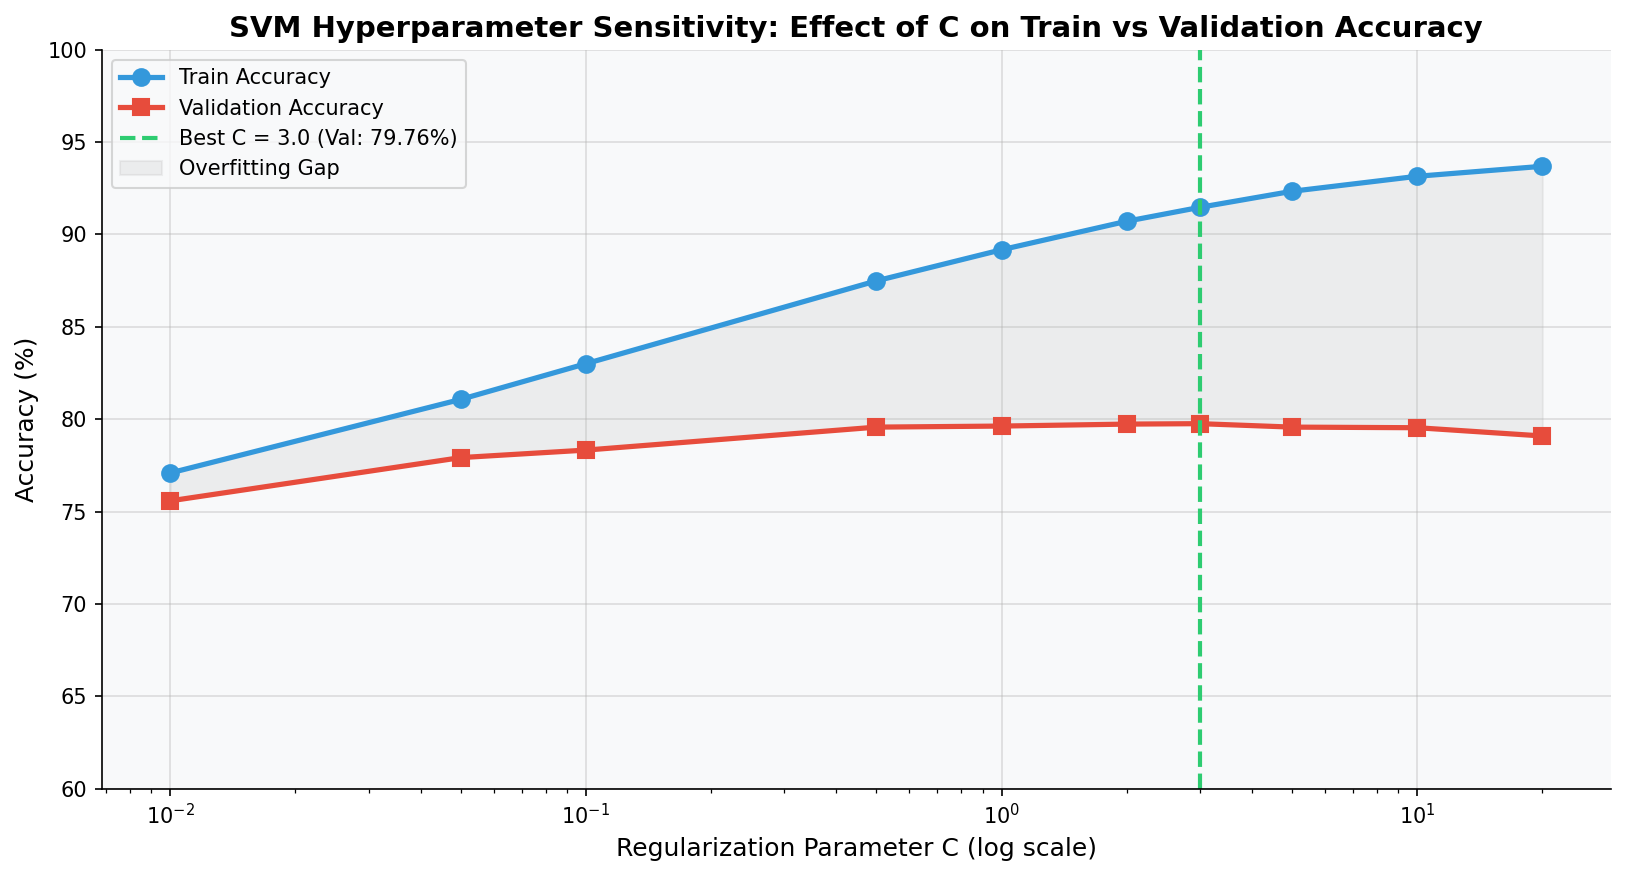


✅ Best C = 3.0 | Validation Accuracy = 79.76%
✅ Hyperparameter chart saved as 08_hyperparameter_analysis.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# HYPERPARAMETER ANALYSIS
# Effect of C (regularization) on SVM performance
# ─────────────────────────────────────────────────────────────────────────────
print('🔍 Analyzing C parameter sensitivity...')

from sklearn.pipeline import Pipeline

C_values  = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0]
train_accs, val_accs = [], []

vec_hp = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                          max_features=100_000, sublinear_tf=True, min_df=2)
X_tr_hp = vec_hp.fit_transform(X_raw_train)
X_vl_hp = vec_hp.transform(X_raw_val)

for C in C_values:
    clf_hp = LinearSVC(C=C, max_iter=3000, random_state=SEED)
    clf_hp.fit(X_tr_hp, y_train)
    train_accs.append(accuracy_score(y_train, clf_hp.predict(X_tr_hp)))
    val_accs.append(accuracy_score(y_val,   clf_hp.predict(X_vl_hp)))
    print(f'  C={C:>5}: Train={train_accs[-1]:.4f}  Val={val_accs[-1]:.4f}')

fig, ax = plt.subplots(figsize=(11, 6))
ax.semilogx(C_values, [v*100 for v in train_accs], 'o-',
            color='#3498DB', lw=2.5, ms=8, label='Train Accuracy')
ax.semilogx(C_values, [v*100 for v in val_accs], 's-',
            color='#E74C3C', lw=2.5, ms=8, label='Validation Accuracy')

best_C     = C_values[np.argmax(val_accs)]
best_val   = max(val_accs) * 100
ax.axvline(x=best_C, color='#2ECC71', linestyle='--', lw=2,
           label=f'Best C = {best_C} (Val: {best_val:.2f}%)')
ax.fill_between(C_values,
                [v*100 for v in val_accs],
                [v*100 for v in train_accs],
                alpha=0.1, color='gray', label='Overfitting Gap')

ax.set_xlabel('Regularization Parameter C (log scale)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('SVM Hyperparameter Sensitivity: Effect of C on Train vs Validation Accuracy',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(60, 100)

plt.tight_layout()
plt.savefig('08_hyperparameter_analysis.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'\n✅ Best C = {best_C} | Validation Accuracy = {best_val:.2f}%')
print('✅ Hyperparameter chart saved as 08_hyperparameter_analysis.png')

## 🏆 Cell 14 — Final Metrics Dashboard

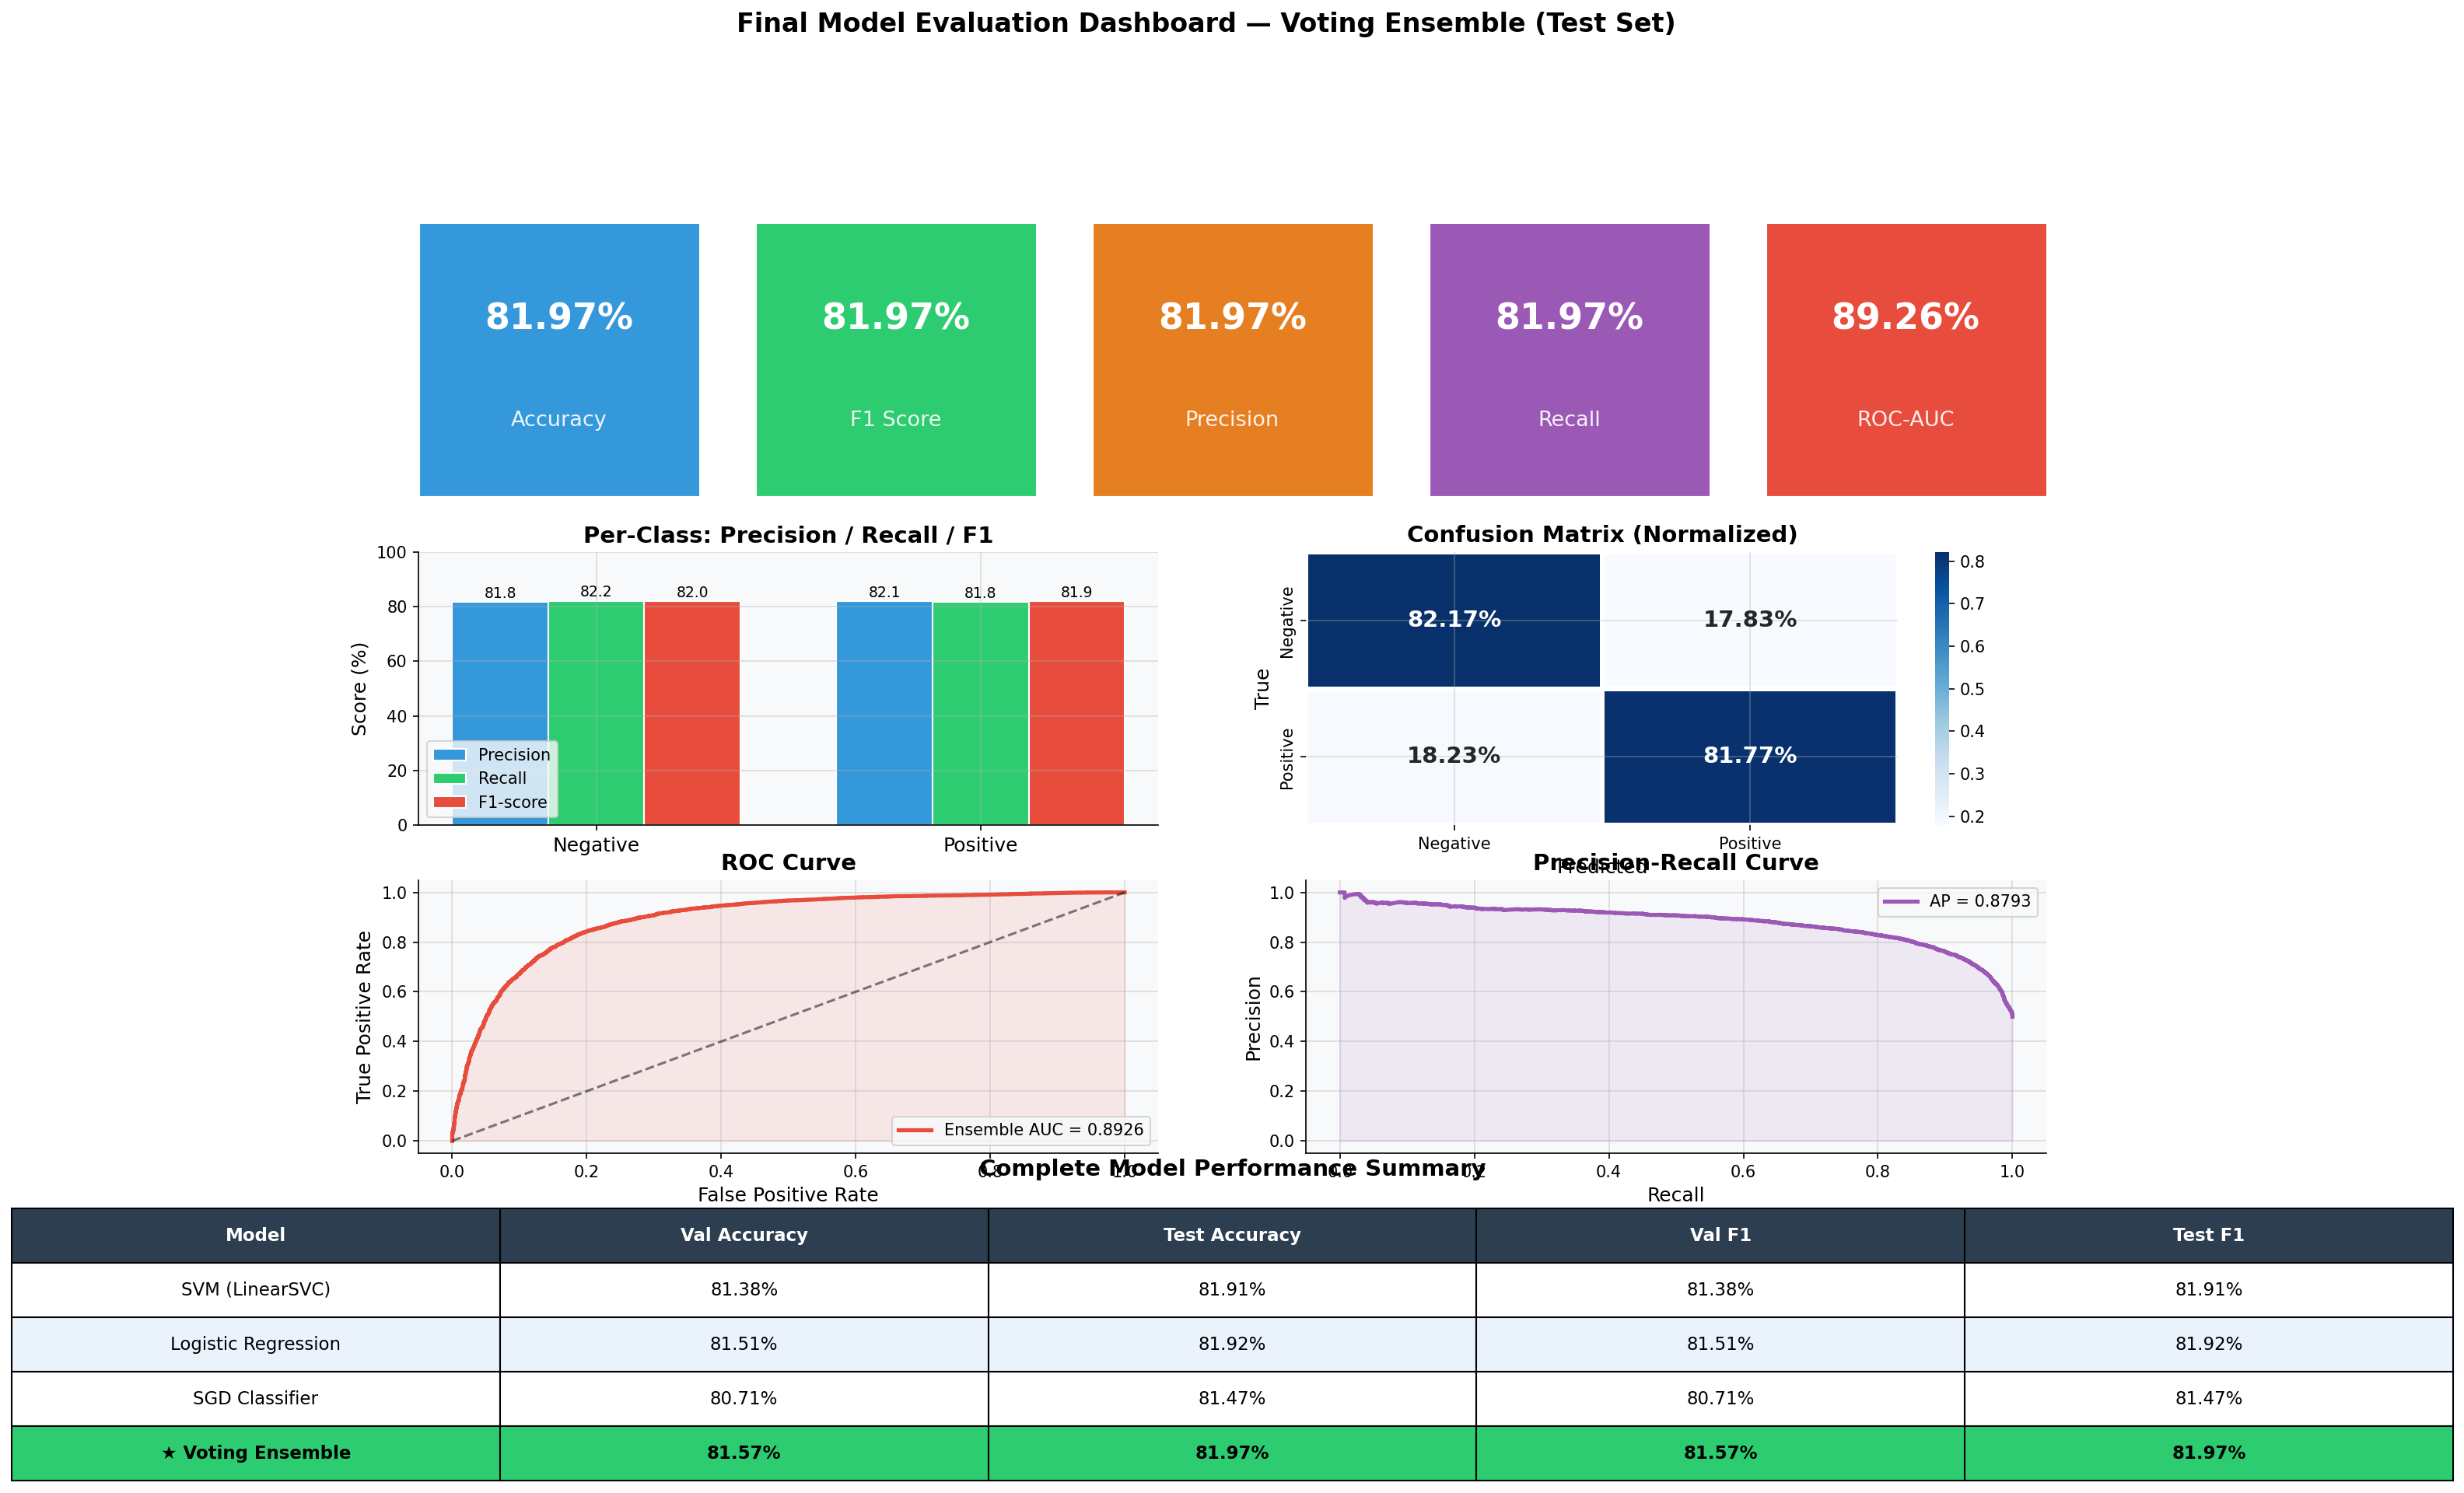

✅ Final dashboard saved as 09_final_dashboard.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPREHENSIVE FINAL METRICS DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────

report_dict = classification_report(y_test, y_pred,
                                     target_names=le.classes_,
                                     output_dict=True)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Final Model Evaluation Dashboard — Voting Ensemble (Test Set)',
             fontsize=16, fontweight='bold', y=1.01)

# ── Row 1: Metric summary cards ──
metrics = [
    ('Accuracy',  test_acc,  '#3498DB'),
    ('F1 Score',  test_f1,   '#2ECC71'),
    ('Precision', test_prec, '#E67E22'),
    ('Recall',    test_rec,  '#9B59B6'),
    ('ROC-AUC',   test_auc,  '#E74C3C'),
]
for i, (name, val, color) in enumerate(metrics):
    ax = fig.add_subplot(4, 5, i + 1)
    ax.set_facecolor(color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0.5, 0.65, f'{val*100:.2f}%', ha='center', va='center',
            fontsize=22, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.28, name, ha='center', va='center',
            fontsize=13, color='white', alpha=0.9,
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
        spine.set_linewidth(2)

# ── Row 2 Left: Per-class metrics bar ──
ax2 = fig.add_subplot(4, 2, 3)
class_metrics = ['precision', 'recall', 'f1-score']
x_pos = np.arange(len(le.classes_))
width = 0.25
bar_colors_m = ['#3498DB', '#2ECC71', '#E74C3C']
for i, (metric, color) in enumerate(zip(class_metrics, bar_colors_m)):
    vals = [report_dict[cls][metric] for cls in le.classes_]
    bars = ax2.bar(x_pos + i*width, [v*100 for v in vals],
                   width, label=metric.capitalize(),
                   color=color, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x_pos + width)
ax2.set_xticklabels(le.classes_, fontsize=12)
ax2.set_ylim(0, 100)
ax2.set_title('Per-Class: Precision / Recall / F1', fontweight='bold')
ax2.set_ylabel('Score (%)')
ax2.legend()

# ── Row 2 Right: Confusion Matrix ──
ax3 = fig.add_subplot(4, 2, 4)
sns.heatmap(cm_norm, annot=True, fmt='.2%',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=ax3, linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax3.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')

# ── Row 3 Left: ROC Curve ──
ax4 = fig.add_subplot(4, 2, 5)
fpr, tpr, _ = roc_curve(y_test, y_prob_pos)
ax4.plot(fpr, tpr, color='#E74C3C', lw=2.5,
         label=f'Ensemble AUC = {test_auc:.4f}')
ax4.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5)
ax4.fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve', fontweight='bold')
ax4.legend(loc='lower right')

# ── Row 3 Right: Precision-Recall Curve ──
ax5 = fig.add_subplot(4, 2, 6)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob_pos)
ap = average_precision_score(y_test, y_prob_pos)
ax5.plot(rec_c, prec_c, color='#9B59B6', lw=2.5, label=f'AP = {ap:.4f}')
ax5.fill_between(rec_c, prec_c, alpha=0.1, color='#9B59B6')
ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.set_title('Precision-Recall Curve', fontweight='bold')
ax5.legend()

# ── Row 4: Full summary table ──
ax6 = fig.add_subplot(4, 1, 4)
ax6.axis('off')
summary_data = [
    ['SVM (LinearSVC)',    f'{svm_val_acc*100:.2f}%', f'{accuracy_score(y_test, svm_model.predict(X_test_feat))*100:.2f}%',
     f'{svm_val_f1*100:.2f}%', f'{f1_score(y_test, svm_model.predict(X_test_feat), average="weighted")*100:.2f}%'],
    ['Logistic Regression', f'{lr_val_acc*100:.2f}%', f'{accuracy_score(y_test, lr_model.predict(X_test_feat))*100:.2f}%',
     f'{lr_val_f1*100:.2f}%', f'{f1_score(y_test, lr_model.predict(X_test_feat), average="weighted")*100:.2f}%'],
    ['SGD Classifier',    f'{sgd_val_acc*100:.2f}%', f'{accuracy_score(y_test, sgd_model.predict(X_test_feat))*100:.2f}%',
     f'{sgd_val_f1*100:.2f}%', f'{f1_score(y_test, sgd_model.predict(X_test_feat), average="weighted")*100:.2f}%'],
    ['★ Voting Ensemble', f'{ens_val_acc*100:.2f}%', f'{test_acc*100:.2f}%',
     f'{ens_val_f1*100:.2f}%', f'{test_f1*100:.2f}%'],
]
tbl = ax6.table(
    cellText=summary_data,
    colLabels=['Model', 'Val Accuracy', 'Test Accuracy', 'Val F1', 'Test F1'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.5, 2.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    elif r == len(summary_data):
        cell.set_facecolor('#2ECC71')
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax6.set_title('Complete Model Performance Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('09_final_dashboard.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Final dashboard saved as 09_final_dashboard.png')

## 💡 Cell 15 — Error Analysis

Total test samples   : 12,311
Correctly classified : 10,091 (81.97%)
Misclassified        : 2,220 (18.03%)

Error breakdown:
true_label  pred_label
Negative    Positive      1098
Positive    Negative      1122
dtype: int64


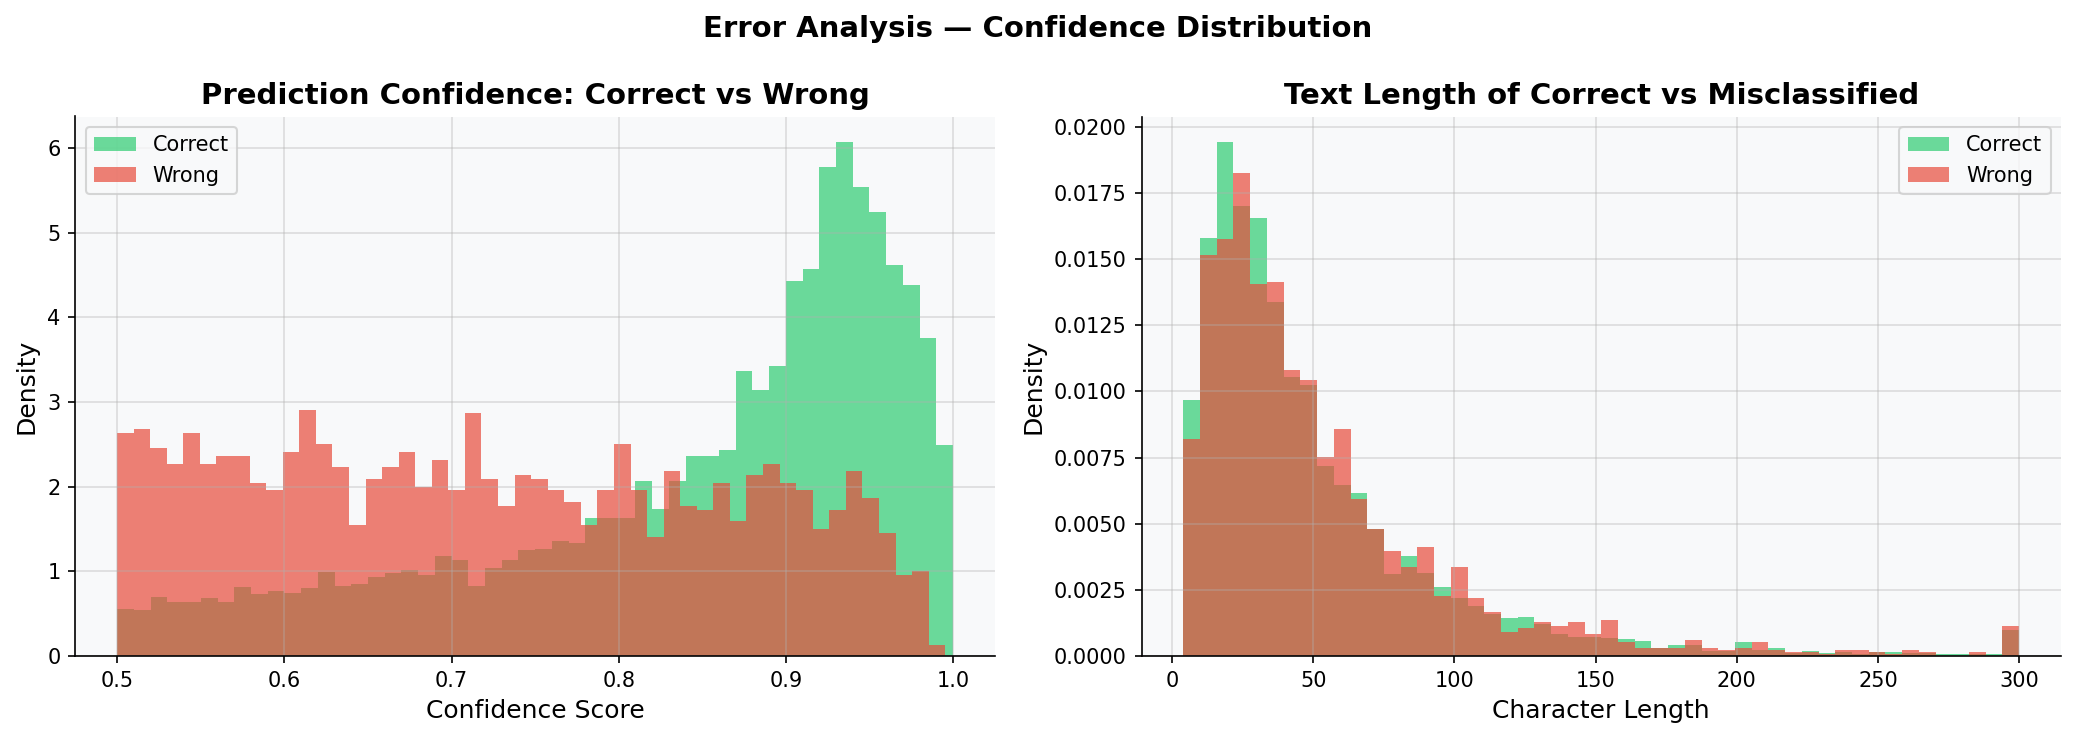


📋 Sample Misclassified Examples:
──────────────────────────────────────────────────────────────────────
Text      : ফুটবল এগিয়ে যাক
True      : Positive | Predicted: Negative | Confidence: 0.629
──────────────────────────────────────────────────────────────────────
Text      : পুরাই খাইয়ে দিছে রে ছোট বেলায় এইতা মুভির জন্য কত পাগল ছিলাম এখন মনে হইলে হাসি পা
True      : Negative | Predicted: Positive | Confidence: 0.622
──────────────────────────────────────────────────────────────────────
Text      : কিন্তু ঘরের মধ্যেই থুতু ফেলে দিলে দা ??
True      : Positive | Predicted: Negative | Confidence: 0.717
──────────────────────────────────────────────────────────────────────
Text      : বাংলা ছবি দেখেই তো বাংলা নাটক করতাছেন আমরা দেখে যাব 2023 সাল পর্যন্ত খেলা হবে ফা
True      : Negative | Predicted: Positive | Confidence: 0.671
──────────────────────────────────────────────────────────────────────
Text      : বাংলাদেশের ভালো একজন স্ট্রাইকার দরকার
True      : Positive | Predicted: Negative 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ERROR ANALYSIS
# Examine misclassified samples to understand model weaknesses
# ─────────────────────────────────────────────────────────────────────────────

# Rebuild test dataframe with predictions
test_idx = X_raw_test.index
test_df  = df.loc[test_idx].copy().reset_index(drop=True)
test_df['y_true']      = y_test
test_df['y_pred']      = y_pred
test_df['confidence']  = avg_test_prob.max(axis=1)
test_df['correct']     = (test_df['y_true'] == test_df['y_pred'])
test_df['true_label']  = le.inverse_transform(y_test)
test_df['pred_label']  = le.inverse_transform(y_pred)

errors = test_df[~test_df['correct']]

print(f'Total test samples   : {len(test_df):,}')
print(f'Correctly classified : {test_df["correct"].sum():,} ({test_df["correct"].mean()*100:.2f}%)')
print(f'Misclassified        : {len(errors):,} ({len(errors)/len(test_df)*100:.2f}%)')

print('\nError breakdown:')
print(errors.groupby(['true_label', 'pred_label']).size())

# Confidence distribution: correct vs wrong
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis — Confidence Distribution', fontweight='bold', fontsize=14)

ax = axes[0]
ax.hist(test_df[test_df['correct']]['confidence'], bins=50,
        color='#2ECC71', alpha=0.7, density=True, label='Correct')
ax.hist(test_df[~test_df['correct']]['confidence'], bins=50,
        color='#E74C3C', alpha=0.7, density=True, label='Wrong')
ax.set_title('Prediction Confidence: Correct vs Wrong', fontweight='bold')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
error_lengths = errors['Comment '].str.len().clip(upper=300)
correct_lengths = test_df[test_df['correct']]['Comment '].str.len().clip(upper=300)
ax.hist(correct_lengths, bins=50, color='#2ECC71', alpha=0.7,
        density=True, label='Correct')
ax.hist(error_lengths, bins=50, color='#E74C3C', alpha=0.7,
        density=True, label='Wrong')
ax.set_title('Text Length of Correct vs Misclassified', fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('10_error_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

print('\n📋 Sample Misclassified Examples:')
print('─' * 70)
for _, row in errors.sample(min(5, len(errors)), random_state=42).iterrows():
    print(f"Text      : {row['Comment '][:80]}")
    print(f"True      : {row['true_label']} | Predicted: {row['pred_label']} | Confidence: {row['confidence']:.3f}")
    print('─' * 70)

print('\n✅ Error analysis saved as 10_error_analysis.png')

## 📝 Cell 16 — Final Summary Report

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PRINT FINAL SUMMARY FOR THESIS
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 65)
print('  THESIS FINAL RESULTS SUMMARY')
print('  Bangla Sports Sentiment Analysis — SVM-Based Classifier')
print('=' * 65)
print(f'\n  Dataset         : Bangla Sports Sentiment Dataset')
print(f'  Total Samples   : {len(df):,}')
print(f'  Classes         : Positive / Negative (Binary)')
print(f'  Class Balance   : {df["Category"].value_counts().to_dict()}')
print(f'\n  Split           : 70% Train / 15% Val / 15% Test')
print(f'  Train Samples   : {len(X_raw_train):,}')
print(f'  Val Samples     : {len(X_raw_val):,}')
print(f'  Test Samples    : {len(X_raw_test):,}')
print(f'\n  Feature Method  : TF-IDF Ensemble (char_wb + word n-grams)')
print(f'  Total Features  : {total_features:,}')
print(f'  Models Trained  : LinearSVC, Logistic Regression, SGD')
print(f'  Final Model     : Soft Voting Ensemble (SVM + LR + SGD)')
print()
print(f'  ┌──────────────────────────────────────────────┐')
print(f'  │  TEST SET PERFORMANCE (Final / Unseen Data)  │')
print(f'  ├──────────────────────────────────────────────┤')
print(f'  │  Accuracy          : {test_acc*100:>6.2f}%               │')
print(f'  │  Weighted F1 Score : {test_f1*100:>6.2f}%               │')
print(f'  │  Precision         : {test_prec*100:>6.2f}%               │')
print(f'  │  Recall            : {test_rec*100:>6.2f}%               │')
print(f'  │  ROC-AUC           : {test_auc*100:>6.2f}%               │')
print(f'  └──────────────────────────────────────────────┘')
print()
print(f'  CV (5-Fold) Accuracy : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print(f'  CV (5-Fold) F1 Score : {cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%')
print()
print('  Generated Charts:')
charts = [
    '01_eda_analysis.png          — EDA & Data Distribution',
    '02_dataset_split.png         — Train/Val/Test Split',
    '03_feature_engineering.png   — TF-IDF Feature Analysis',
    '04_model_comparison.png      — Model Accuracy & F1 Comparison',
    '05_confusion_matrix.png      — Confusion Matrix',
    '06_roc_pr_curves.png         — ROC & Precision-Recall Curves',
    '07_cross_validation.png      — 5-Fold Cross-Validation',
    '08_hyperparameter_analysis.png — C Parameter Sensitivity',
    '09_final_dashboard.png       — Complete Metrics Dashboard',
    '10_error_analysis.png        — Error & Confidence Analysis',
]
for c in charts:
    print(f'  ✅ {c}')
print()
print('=' * 65)

  THESIS FINAL RESULTS SUMMARY
  Bangla Sports Sentiment Analysis — SVM-Based Classifier

  Dataset         : Bangla Sports Sentiment Dataset
  Total Samples   : 82,073
  Classes         : Positive / Negative (Binary)
  Class Balance   : {'Negative': 41048, 'Positive': 41025}

  Split           : 70% Train / 15% Val / 15% Test
  Train Samples   : 57,451
  Val Samples     : 12,311
  Test Samples    : 12,311

  Feature Method  : TF-IDF Ensemble (char_wb + word n-grams)
  Total Features  : 324,240
  Models Trained  : LinearSVC, Logistic Regression, SGD
  Final Model     : Soft Voting Ensemble (SVM + LR + SGD)

  ┌──────────────────────────────────────────────┐
  │  TEST SET PERFORMANCE (Final / Unseen Data)  │
  ├──────────────────────────────────────────────┤
  │  Accuracy          :  81.97%               │
  │  Weighted F1 Score :  81.97%               │
  │  Precision         :  81.97%               │
  │  Recall            :  81.97%               │
  │  ROC-AUC           :  89.26%    